## Chapter 1 of *lme4: Mixed-effects modeling with R* (2022)

In [1]:
from hea.R import *
from hea.plot import *
from hea import data, lm, lme

### 2.1.1

In [2]:
penicillin = data("Penicillin", "lme4")
summary(penicillin)

  diameter        plate     sample
Min.   :18.00  a      :  6  A:24
1st Qu.:22.00  b      :  6  B:24
Median :23.00  c      :  6  C:24
Mean   :22.97  d      :  6  D:24
3rd Qu.:24.00  e      :  6  E:24
Max.   :27.00  f      :  6  F:24
               (Other):108

In [3]:
fm03 = lme('diameter ~ 1 + (1 | plate) + (1 | sample)', penicillin)
summary(fm03)

Linear mixed model fit by REML
Formula: diameter ~ 1 + (1 | plate) + (1 | sample)

REML criterion at convergence: 330.8606

Scaled residuals:
    Min      1Q Median     3Q    Max
-2.0794 -0.6714 0.0629 0.5838 2.9798

Random effects:
 Groups   Name        Variance Std.Dev.
 plate    (Intercept) 0.7172   0.8468
 sample   (Intercept) 3.7359   1.9328
 Residual             0.3024   0.5499
Number of obs: 144, groups:  plate, 24; sample, 6

Fixed effects:
             Estimate  Std. Error  t value
(Intercept)   22.9722      0.8091    28.39


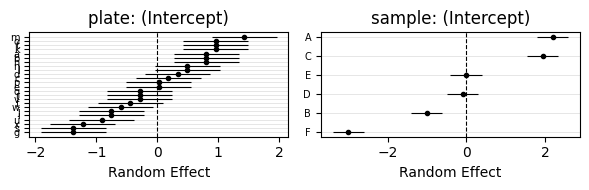

In [4]:
_ = fm03.plot_ranef(figsize=(6, 2))

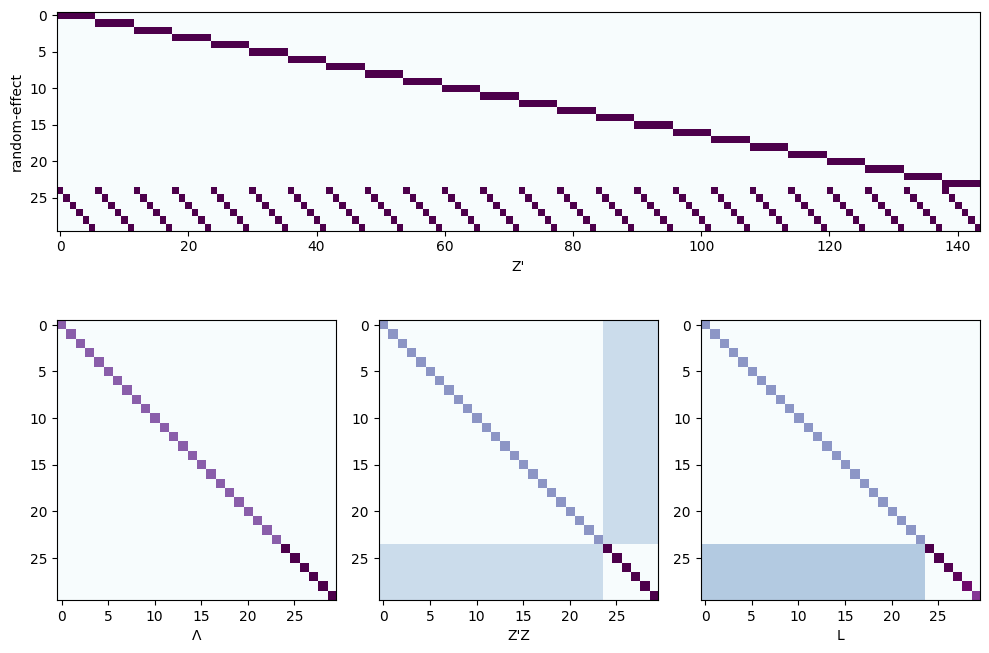

In [5]:
_ = fm03.plot_design()

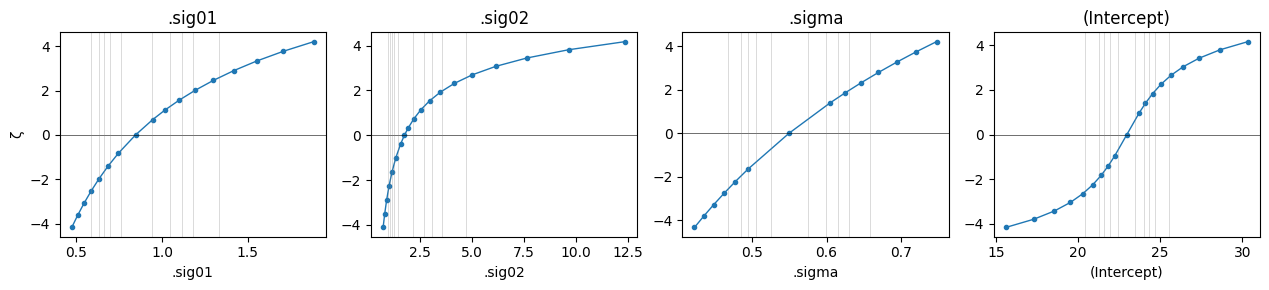

In [6]:
pr03 = fm03.profile()
_ = pr03.plot()

In [7]:
confint(pr03)

parameter,2.5%,97.5%
str,f64,f64
""".sig01""",0.633565,1.182102
""".sig02""",1.09575,3.556312
""".sigma""",0.485846,0.629453
"""(Intercept)""",21.26662,24.677825


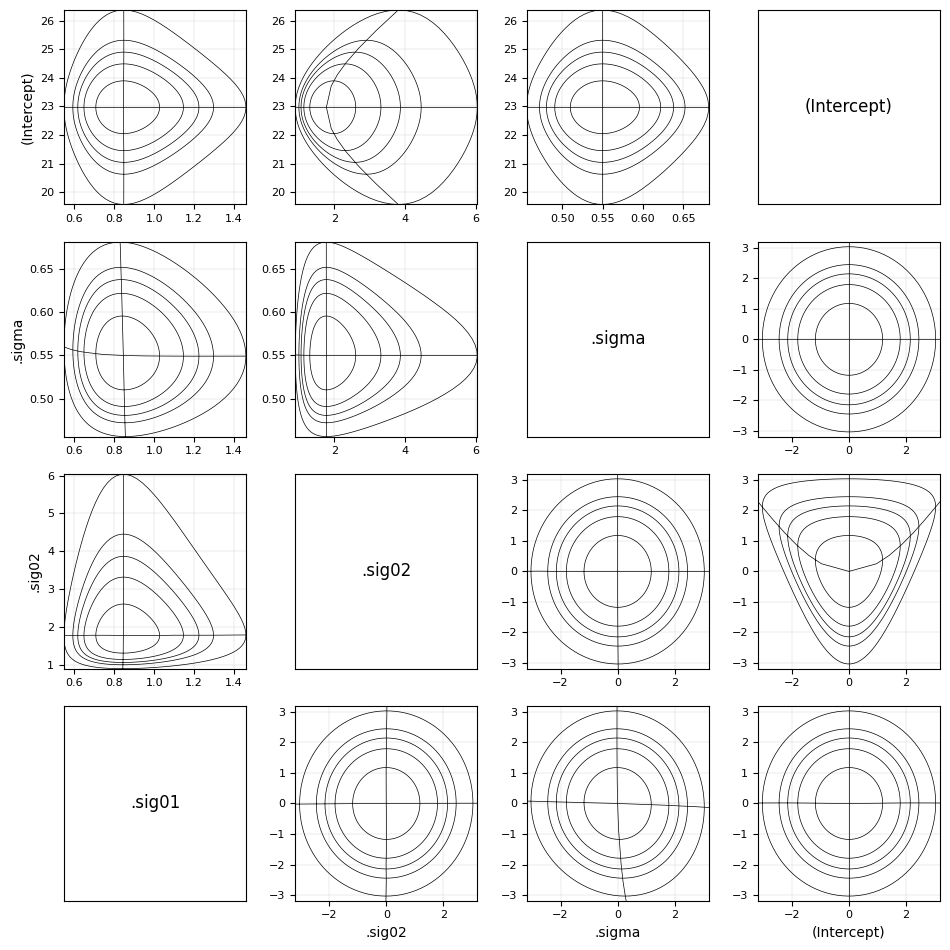

In [8]:
_ = pr03.plot_pairs()

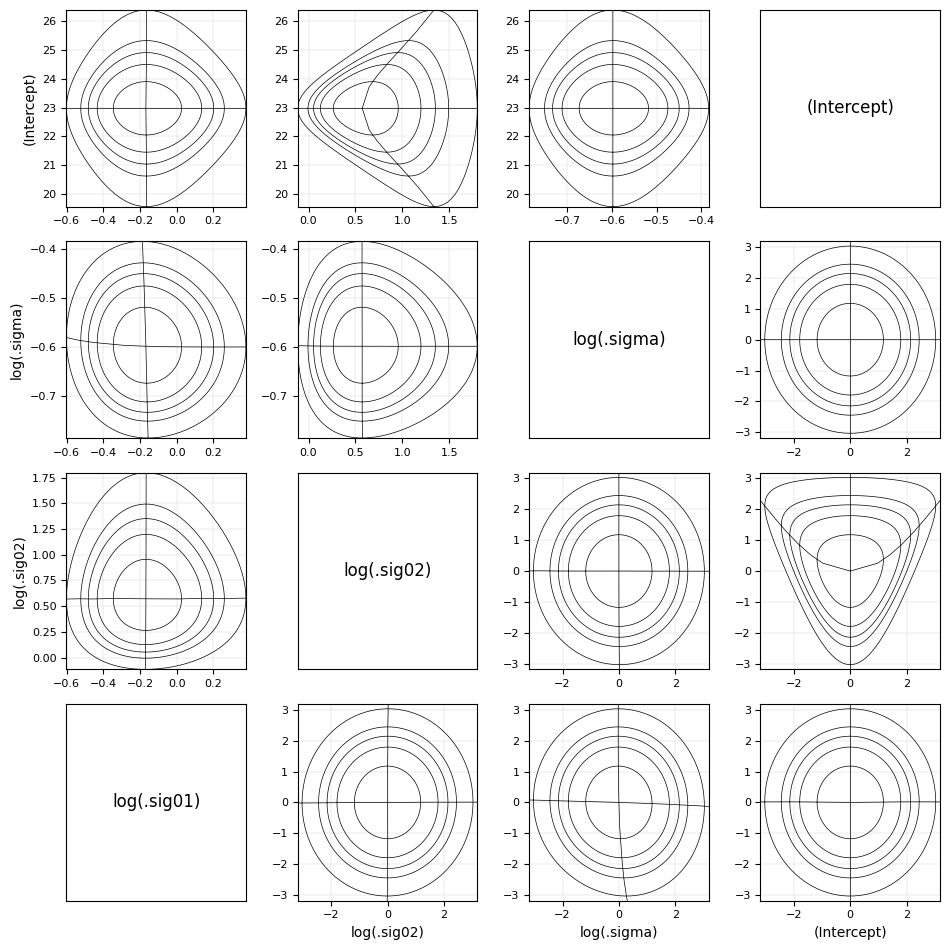

In [9]:
_ = pr03.plot_pairs(transform="log")

### 2.2.1

In [10]:
pastes = data("Pastes", "lme4")
summary(pastes)

  strength       batch     cask    sample
Min.   :54.20  A      : 6  a:20  A:a    : 2
1st Qu.:57.50  B      : 6  b:20  A:b    : 2
Median :59.30  C      : 6  c:20  A:c    : 2
Mean   :60.05  D      : 6        B:a    : 2
3rd Qu.:62.88  E      : 6        B:b    : 2
Max.   :66.00  F      : 6        B:c    : 2
               (Other):24        (Other):48

In [11]:
fm04 = lme('strength ~ 1 + (1 | sample) + (1 | batch)', pastes, REML=False)
summary(fm04)

Linear mixed model fit by maximum likelihood
Formula: strength ~ 1 + (1 | sample) + (1 | batch)

     AIC      BIC    logLik -2*log(L) df.resid
255.9945 264.3718 -123.9972  247.9945       56

Scaled residuals:
    Min      1Q Median     3Q    Max
-1.4847 -0.5263 0.0122 0.4674 1.3892

Random effects:
 Groups   Name        Variance Std.Dev.
 sample   (Intercept) 8.436    2.9045
 batch    (Intercept) 1.197    1.0939
 Residual             0.678    0.8234
Number of obs: 60, groups:  sample, 30; batch, 10

Fixed effects:
             Estimate  Std. Error  t value
(Intercept)   60.0533      0.6420    93.54


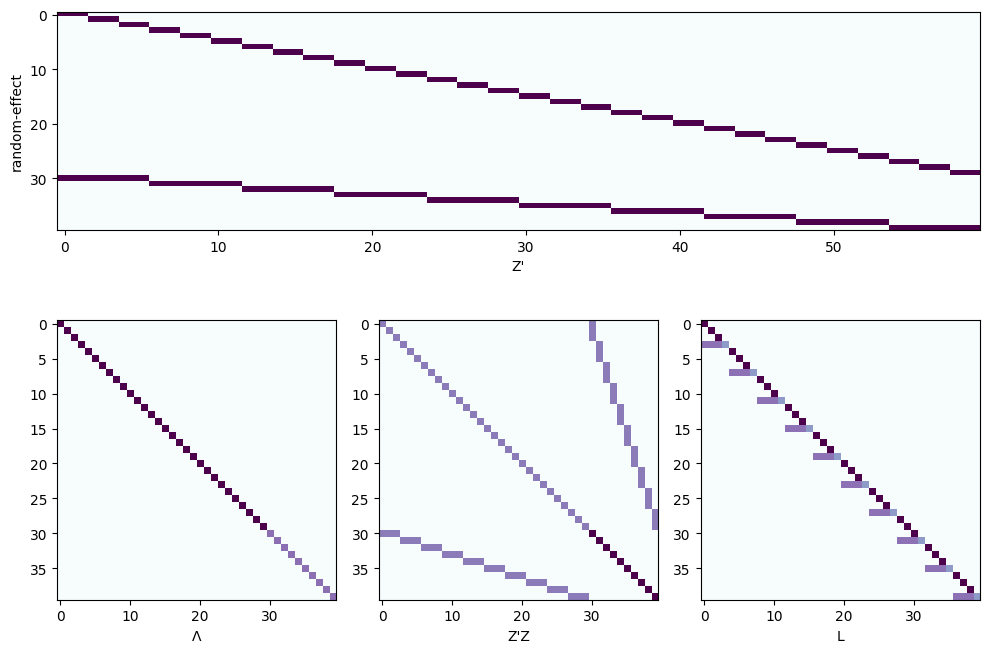

In [12]:
_ = fm04.plot_design()

In [13]:
fm04a = lme('strength ~ 1 + (1 | sample)', pastes, REML=False)
summary(fm04a)

Linear mixed model fit by maximum likelihood
Formula: strength ~ 1 + (1 | sample)

     AIC      BIC    logLik -2*log(L) df.resid
254.4017 260.6847 -124.2009  248.4017       57

Scaled residuals:
    Min      1Q Median     3Q    Max
-1.4919 -0.5415 0.0150 0.4621 1.3884

Random effects:
 Groups   Name        Variance Std.Dev.
 sample   (Intercept) 9.6355   3.1041
 Residual             0.6778   0.8233
Number of obs: 60, groups:  sample, 30

Fixed effects:
             Estimate  Std. Error  t value
(Intercept)   60.0533      0.5766    104.1
